# Phase 1 — Structural metadata deep dive

**Notebook owner:** Katia
**Phase:** 1 / 9 of the classifier workflow
**Depends on:** `exploration.ipynb` (already establishes the table landscape and the AIBS canonical label choice).
**Feeds into:** Phase 2 (functional inventory) and Phase 3 (label & population decision).

---

## Goal

Understand every filter and flag that `microns-datacleaner` exposes on the **structural side**, so that when we pick the training population in Phase 3 we can justify each choice with numbers instead of defaults.

In practice, this notebook answers six questions:

1. What does each value of the `functional_data=` argument in `process_nucleus_data()` change in the output?
2. What is `tuning_type` and who is `matched` vs `not_matched`?
3. What do the proofreading fields (`status_axon`, `status_dendrite`, `strategy_*`) mean, and should we filter by them?
4. What is `cc_abs`, how is it distributed, and would a quality threshold help?
5. What is the relationship between the manual coregistration table and the automatic one, and which is safer to trust?
6. Under several candidate filter combinations, how many neurons per (brain_area × layer × cell_type) do we actually end up with?

## Deliverables

- A **decision table** at the end that summarises the population size under each candidate filter combo.
- A short **takeaways** markdown block stating *which filters we will adopt* in Phase 3, with reasons.
- A persisted `data/derived/phase1_candidate_population.parquet` we can reuse downstream (tentative — Phase 3 may tighten it further).

## Constraint reminder

Per `CLAUDE.md`, the final **classifier input** must be functional-only. Labels (cell_type, layer, brain_area) are structural and are fine as targets. Structural fields we investigate here (proofreading status, coregistration source, cc_abs) are decision levers for filtering/quality control, not classifier inputs.


## 0. Setup

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 110


We use the two cleaners already set up in `exploration.ipynb`:
- `cleaner_min` → `download_policy='minimum'` (7 essential tables).
- `cleaner_all` → `download_policy='all'` (27+ tables including the extra cell-type and coregistration sources).

Both point at dataset **version 1718**.


In [2]:
cleaner_min = mic.MicronsDataCleaner(datadir='data/data_min', version=1718, download_policy='minimum')
cleaner_all = mic.MicronsDataCleaner(datadir='data/data_all', version=1718, download_policy='all')

print('cleaner_min supported versions:', mic.MicronsDataCleaner.SUPPORTED_VERSIONS)
print('cleaner_min version in use   :', cleaner_min.version)


cleaner_min supported versions: [1078, 1181, 1300, 1412, 1507, 1621, 1718]
cleaner_min version in use   : 1718


---

## 1. `process_nucleus_data(functional_data=...)` — the four modes

`process_nucleus_data` is the main entry point for building the consolidated neuron table.
The `functional_data` argument controls **how functional-side information is attached**.

Possible values (from the tutorial + the library source):

| Value | Meaning |
|---|---|
| `None` | No functional columns. Purely structural units table. |
| `'match'` | Keep **all coregistered** rows. If a neuron was matched to multiple scans, it appears on **multiple rows** (one per session × scan × unit_id). |
| `'all'` | Full multi-scan expansion — adds tuning columns for every scan a neuron was seen in. |
| `'best_only'` | Keep only the single scan with the highest `cc_abs` per nucleus. Unique `nucleus_id`. |

We need to **see the actual effect** (row counts, which columns appear/disappear, whether nucleus_id is unique).


### 1.1 — `functional_data=None`

In [3]:
units_none, segments_none = cleaner_min.process_nucleus_data(functional_data=None)
print('shape                :', units_none.shape)
print('unique nucleus_id    :', units_none['nucleus_id'].nunique())
print('unique pt_root_id    :', units_none['pt_root_id'].nunique())
print('has session column   :', 'session' in units_none.columns)
print('has cc_abs column    :', 'cc_abs' in units_none.columns)
print('columns:')
print(units_none.columns.tolist())


Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 73851.21it/s]


shape                : (90434, 12)
unique nucleus_id    : 90434
unique pt_root_id    : 90434
has session column   : False
has cc_abs column    : False
columns:
['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'tuning_type', 'layer']


### 1.2 — `functional_data='match'`

In [30]:
units_match, segments_match = cleaner_min.process_nucleus_data(functional_data='match')
print('shape                :', units_match.shape)
print('unique nucleus_id    :', units_match['nucleus_id'].nunique())
print('duplication ratio    :', len(units_match) / units_match['nucleus_id'].nunique())
print()
print('columns added vs None:')
added = sorted(set(units_match.columns) - set(units_none.columns))
for c in added:
    print('  +', c)


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 121907.86it/s]


shape                : (94167, 15)
unique nucleus_id    : 90434
duplication ratio    : 1.0412787226043303

columns added vs None:
  + functional_unit_id
  + scan_idx
  + session


In [5]:
# How many neurons appear in >1 scan?
dup = units_match.groupby('nucleus_id').size()
print('scans per nucleus (distribution):')
print(dup.value_counts().sort_index())
print()
print(f'neurons with multi-scan entries: {(dup > 1).sum()}')


scans per nucleus (distribution):
1    87184
2     2809
3      400
4       40
5        1
Name: count, dtype: int64

neurons with multi-scan entries: 3250


### 1.3 — `functional_data='all'`

In [6]:
units_all, segments_all = cleaner_min.process_nucleus_data(functional_data='all')
print('shape                :', units_all.shape)
print('unique nucleus_id    :', units_all['nucleus_id'].nunique())

# Difference vs 'match': which columns are added?
added_vs_match = sorted(set(units_all.columns) - set(units_match.columns))
print(f'\ncolumns in `all` but not in `match` ({len(added_vs_match)}):')
for c in added_vs_match:
    print('  +', c)


Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 71037.39it/s]


shape                : (93117, 20)
unique nucleus_id    : 90434

columns in `all` but not in `match` (5):
  + cc_abs
  + gDSI
  + gOSI
  + pref_dir
  + pref_ori


### 1.4 — `functional_data='best_only'`

In [7]:
units_best, segments_best = cleaner_min.process_nucleus_data(functional_data='best_only')
print('shape                :', units_best.shape)
print('unique nucleus_id    :', units_best['nucleus_id'].nunique())
print('unique pt_root_id    :', units_best['pt_root_id'].nunique())
print()
# Key question from the tutorial: does `best_only` keep session/scan_idx/unit_id?
for col in ['session', 'scan_idx', 'unit_id', 'functional_unit_id', 'cc_abs', 'tuning_type']:
    present = col in units_best.columns
    nonnull = units_best[col].notna().sum() if present else 0
    print(f'  {col:22s} present={present}  non-null={nonnull}')


Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 75742.55it/s]


shape                : (90434, 20)
unique nucleus_id    : 90434
unique pt_root_id    : 90434

  session                present=True  non-null=13005
  scan_idx               present=True  non-null=13005
  unit_id                present=True  non-null=13005
  functional_unit_id     present=False  non-null=0
  cc_abs                 present=True  non-null=13005
  tuning_type            present=True  non-null=90434


**Sanity check.** The tutorial says "best_only does not give information about session, scan or unit id" but Katia's `exploration.ipynb` cell 36 reported those columns as present under `best_only`. The cell above prints the ground truth in our installed version of the package — one of the two statements is outdated, and this tells us which.


### 1.5 — Side-by-side summary

In [8]:
summary = pd.DataFrame({
    'rows':             [len(units_none), len(units_match), len(units_all), len(units_best)],
    'unique_nuclei':    [units_none['nucleus_id'].nunique(),
                         units_match['nucleus_id'].nunique(),
                         units_all['nucleus_id'].nunique(),
                         units_best['nucleus_id'].nunique()],
    'has_session':      ['session' in d.columns for d in [units_none, units_match, units_all, units_best]],
    'has_cc_abs':       ['cc_abs'  in d.columns for d in [units_none, units_match, units_all, units_best]],
    'has_tuning_type':  ['tuning_type' in d.columns for d in [units_none, units_match, units_all, units_best]],
}, index=['None', 'match', 'all', 'best_only'])
summary.index.name = 'functional_data='
summary


,rows,unique_nuclei,has_session,has_cc_abs,has_tuning_type
functional_data=,,,,,
None,90434,90434,False,False,True
match,94167,90434,True,False,True
all,93117,90434,True,True,True
best_only,90434,90434,True,True,True


**Takeaway (Section 1):**

- For the classifier we want one row per neuron to avoid train/test leakage from multi-scan duplicates → candidates are `None` or `best_only`.
- We also want access to the functional-side metadata (`cc_abs`, `session`, `scan_idx`, `unit_id` to reach the H5) → `best_only` is the only mode that gives us both.
- We will keep `units_match` separately for diagnostics: it is the only mode that retains every (session, scan) pair a neuron appeared in, useful for session-level coverage tables in Section 6.

**Decision for downstream:** use `units_best` as the canonical neuron table, cross-reference `units_match` for per-scan breakdowns.


---

## 2. `tuning_type` — who is matched, who is not

`tuning_type` is the column that tells you *how* a neuron was connected to functional data:

- `matched` → the neuron has a coregistered functional recording (via manual or automatic coregistration).
- `not_matched` → no functional recording found for this neuron.

Anything classifier-trainable must be in the matched population.


In [9]:
# tuning_type is only present in modes that touch functional data.
# Work on units_match (keeps all scans; most complete tuning_type coverage).
print('tuning_type distribution in units_match:')
print(units_match['tuning_type'].value_counts(dropna=False))
print()
print('tuning_type distribution in units_best:')
print(units_best['tuning_type'].value_counts(dropna=False))


tuning_type distribution in units_match:
tuning_type
not_matched    75090
matched        19077
Name: count, dtype: int64

tuning_type distribution in units_best:
tuning_type
not_matched    77429
matched        13005
Name: count, dtype: int64


In [10]:
# Matched fraction per (brain_area × classification_system), on units_best so each nucleus counts once.
if 'tuning_type' in units_best.columns:
    base = units_best.drop_duplicates('nucleus_id').copy()
    base['is_matched'] = (base['tuning_type'] == 'matched')
    ct = base.groupby(['brain_area', 'classification_system'])['is_matched'].agg(['sum', 'count'])
    ct['matched_pct'] = (100 * ct['sum'] / ct['count']).round(1)
    ct = ct.rename(columns={'sum': 'matched', 'count': 'total'})
    display(ct.sort_values('matched', ascending=False).head(20))


,,matched,total,matched_pct
brain_area,classification_system,,,
V1,excitatory_neuron,8910,42127,21.2
RL,excitatory_neuron,3199,14673,21.8
AL,excitatory_neuron,809,6797,11.9
V1,inhibitory_neuron,43,4921,0.9
LM,excitatory_neuron,20,225,8.9
RL,inhibitory_neuron,15,1889,0.8
AL,inhibitory_neuron,5,1012,0.5
V1,nonneuron,4,12153,0.0
AL,nonneuron,0,2050,0.0


In [11]:
# Same breakdown but restricted to excitatory neurons (the classifier's target population).
exc_best = units_best[units_best['classification_system'] == 'excitatory_neuron'].drop_duplicates('nucleus_id')
exc_best_matched = exc_best[exc_best['tuning_type'] == 'matched']

print('Excitatory neurons (unique):', len(exc_best))
print('Excitatory matched         :', len(exc_best_matched))
print(f'Match rate                 : {100*len(exc_best_matched)/len(exc_best):.1f}%')
print()
print('Matched excitatory by area:')
print(exc_best_matched['brain_area'].value_counts(dropna=False))


Excitatory neurons (unique): 63822
Excitatory matched         : 12938
Match rate                 : 20.3%

Matched excitatory by area:
brain_area
V1    8910
RL    3199
AL     809
LM      20
Name: count, dtype: int64


**Takeaway (Section 2):** we already lose most neurons at this step — only a fraction of excitatory neurons are matched to functional data. This is the real bottleneck on training-set size. Cell counts above will guide Section 6 and Phase 3.

---

## 3. Proofreading fields

Four columns carry proofreading information. These encode **how trusted the axon and dendrite reconstructions are** for each neuron:

- `strategy_axon` / `strategy_dendrite` — *how* the cell was proofread (e.g. `axon_fully_extended`, `dendrite_clean`).
- `status_axon` / `status_dendrite` — *a compact status tag* (`clean`, `extended`, `unknown`, …).

Why do we care for a classifier that uses only functional data?

- **Label trust**: if a neuron has a poorly-reconstructed nucleus, its AIBS `cell_type` label may itself be noisy (many of the AIBS labels are inferred from morphology, which uses the reconstruction).
- **NOT as an input feature** — proofreading is structural info and the constraint forbids it as classifier input.

So in practice proofreading flags become **filters on label quality**, optionally used to build a high-confidence training subset.


In [12]:
# Value counts for each proofreading column on unique neurons.
pr_cols = ['strategy_axon', 'strategy_dendrite', 'status_axon', 'status_dendrite']
u = units_best.drop_duplicates('nucleus_id')
for col in pr_cols:
    if col in u.columns:
        print(f'\n=== {col} ===')
        print(u[col].value_counts(dropna=False).head(15))



=== strategy_axon ===
strategy_axon
none                       88242
axon_partially_extended     1554
axon_fully_extended          518
axon_interareal              120
Name: count, dtype: int64

=== strategy_dendrite ===
strategy_dendrite
none                 88203
dendrite_extended     1802
dendrite_clean         429
Name: count, dtype: int64


In [13]:
# How do the four fields combine? Joint 'axon × dendrite' status counts for matched excitatory neurons.
if all(c in u.columns for c in ['status_axon', 'status_dendrite']):
    mask = (u['classification_system'] == 'excitatory_neuron') & (u['tuning_type'] == 'matched')
    ct = pd.crosstab(u.loc[mask, 'status_axon'].fillna('<NA>'),
                     u.loc[mask, 'status_dendrite'].fillna('<NA>'),
                     margins=True, margins_name='total')
    display(ct)


In [15]:
# What does fl.filter_neurons(proofread='ax_clean') actually filter?
# Compare population size at several proofread levels.
combos = ['ax_clean', 'den_clean', 'ax_extended', 'ax_clean_den_clean']
rows = []
for pr in combos:
    try:
        sub = fl.filter_neurons(units_best, proofread=pr, tuning='matched',
                                 cell_type='excitatory_neuron')
        rows.append({'proofread': pr, 'n_rows': len(sub),
                     'n_unique_nuclei': sub['nucleus_id'].nunique()})
    except Exception as e:
        rows.append({'proofread': pr, 'n_rows': 'ERROR: ' + str(e)[:60], 'n_unique_nuclei': None})
pd.DataFrame(rows)


,proofread,n_rows,n_unique_nuclei
0,ax_clean,906,906
1,den_clean,12938,12938
2,ax_extended,12764,12764
3,ax_clean_den_clean,12938,12938


**Takeaway (Section 3):** proofreading is a *label-quality* lever, not a feature. We will run the baseline classifier on the full matched-excitatory set first, and then in Phase 8 (controls) compare against a proofread-clean subset to quantify how much label noise from unproofread neurons costs us in accuracy.

---

## 4. `cc_abs` — functional-quality score

`cc_abs` is the absolute correlation coefficient between the neuron's recorded response and the prediction of the digital-twin functional model (BCM Baylor team). It is a **per-neuron quality score**:

- Higher (→1) = neuron's activity is well-explained by the twin model. These are the neurons whose tuning curves are reliable.
- Lower (→0) = noisier / harder-to-model neuron. Its functional features will be unreliable.

`cc_abs` is only defined for matched neurons and comes from `digital_twin_properties_bcm_coreg_v4`.


In [16]:
# cc_abs distribution on matched excitatory neurons (units_best gives us one value per neuron: the best scan's cc_abs).
m = (units_best['classification_system'] == 'excitatory_neuron') & (units_best['tuning_type'] == 'matched')
cc = units_best.loc[m, 'cc_abs']
print(f'n matched excitatory neurons with cc_abs: {cc.notna().sum()}')
print(f'missing cc_abs                           : {cc.isna().sum()}')
print('\nquantiles:')
print(cc.describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(3))


n matched excitatory neurons with cc_abs: 12938
missing cc_abs                           : 0

quantiles:
count    12938.000
mean         0.413
std          0.174
min         -0.111
5%           0.135
10%          0.190
25%          0.288
50%          0.407
75%          0.534
90%          0.651
95%          0.709
max          0.959
Name: cc_abs, dtype: float64


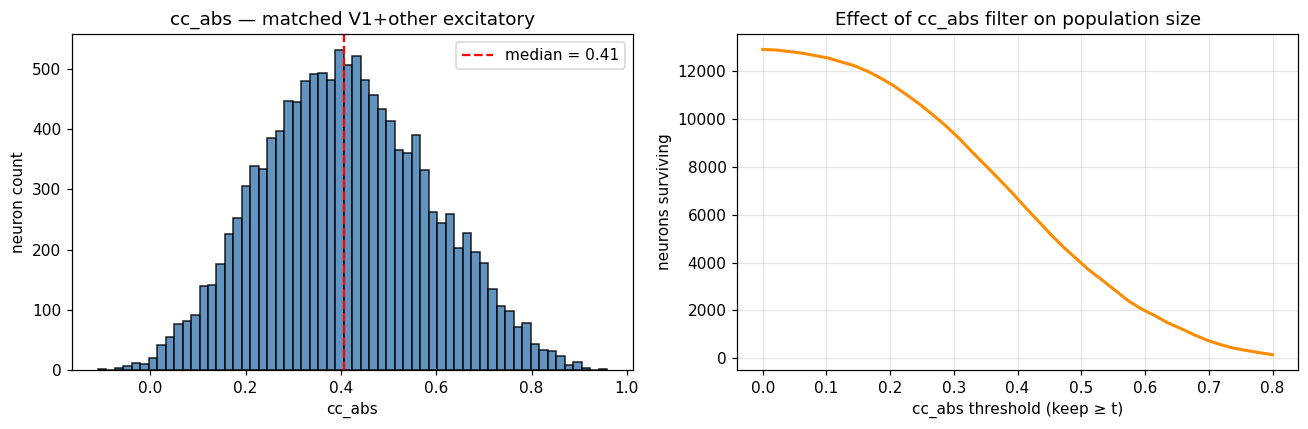

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cc.dropna(), bins=60, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('cc_abs')
axes[0].set_ylabel('neuron count')
axes[0].set_title('cc_abs — matched V1+other excitatory')
axes[0].axvline(cc.median(), color='red', linestyle='--', label=f'median = {cc.median():.2f}')
axes[0].legend()

# Population size that survives at each cc_abs threshold.
thresholds = np.linspace(0, 0.8, 40)
n_keep = [(cc >= t).sum() for t in thresholds]
axes[1].plot(thresholds, n_keep, color='darkorange', linewidth=2)
axes[1].set_xlabel('cc_abs threshold (keep ≥ t)')
axes[1].set_ylabel('neurons surviving')
axes[1].set_title('Effect of cc_abs filter on population size')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [18]:
# cc_abs by layer and by cell_type — is quality confounded with class?
from microns_datacleaner import filters as _fl
# Attach layer via filters (same trick as exploration.ipynb cell 40).
layers = ['L1', 'L2/3', 'L4', 'L5', 'L6']
ub = units_best.copy()
layer_col = pd.Series(pd.NA, index=ub.index, dtype='object')
for L in layers:
    sub = _fl.filter_neurons(ub, layer=L)
    layer_col.loc[sub.index] = L
ub['layer'] = layer_col

m = (ub['classification_system'] == 'excitatory_neuron') & (ub['tuning_type'] == 'matched')
sub = ub.loc[m & ub['cc_abs'].notna()].drop_duplicates('nucleus_id')

print('median cc_abs by layer:')
print(sub.groupby('layer')['cc_abs'].median().round(3))
print()
print('median cc_abs by cell_type:')
print(sub.groupby('cell_type')['cc_abs'].median().round(3))


median cc_abs by layer:
layer
L1      0.381
L2/3    0.389
L4      0.424
L5      0.460
L6      0.265
Name: cc_abs, dtype: float64

median cc_abs by cell_type:
cell_type
23P      0.387
4P       0.425
5P-ET    0.466
5P-IT    0.458
5P-NP    0.388
6P-CT    0.236
6P-IT    0.275
Name: cc_abs, dtype: float64


**Takeaway (Section 4):**

- `cc_abs` is a legitimate quality filter that does not leak label information (it measures model fit, not morphology).
- We record two candidate thresholds to revisit: `cc_abs ≥ 0.2` (loose) and `cc_abs ≥ 0.3` (stricter).
- Check the per-layer and per-cell_type median: if some classes have systematically lower `cc_abs` than others, a hard threshold will aggressively unbalance them, which matters for the L5/L6 subtype question. Decide in Phase 7 whether to use a hard cutoff or `cc_abs` as a sample weight.


---

## 5. Coregistration — manual vs automatic

Two coregistration tables map nuclei to functional units:

- `coregistration_manual_v4` — hand-curated by humans, highest quality, smaller.
- `coregistration_auto_phase3_fwd_apl_vess_combined_v2` — algorithmic, bigger, with a `score` column that ranks match confidence.

Katia's `exploration.ipynb` worked with the manual table; the tutorial shows how to merge the auto table into `units`. Here we quantify the overlap and decide which to use.


In [20]:
coreg_manual = cleaner_min.read_table('coregistration_manual_v4')
coreg_auto   = cleaner_all.read_table('coregistration_auto_phase3_fwd_apl_vess_combined_v2')

print('manual coreg: shape', coreg_manual.shape, ' unique target_id', coreg_manual['target_id'].nunique())
print('auto coreg  : shape', coreg_auto.shape,   ' unique target_id', coreg_auto['target_id'].nunique())
print()
print('manual columns:', coreg_manual.columns.tolist())
print('auto columns  :', coreg_auto.columns.tolist())


manual coreg: shape (19181, 25)  unique target_id 15439
auto coreg  : shape (83046, 25)  unique target_id 35772

manual columns: ['id', 'created', 'valid', 'target_id', 'session', 'scan_idx', 'unit_id', 'field', 'residual', 'score', 'id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id']
auto columns  : ['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id', 'id', 'created', 'valid', 'target_id', 'session', 'scan_idx', 'unit_id', 'field', 'residual', 'score']


In [21]:
# Overlap: which nuclei are in manual only, auto only, or both.
manual_ids = set(coreg_manual['target_id'].dropna().astype(int))
auto_ids   = set(coreg_auto['target_id'].dropna().astype(int))

both = manual_ids & auto_ids
manual_only = manual_ids - auto_ids
auto_only   = auto_ids - manual_ids

print(f'in manual & auto   : {len(both)}')
print(f'in manual only     : {len(manual_only)}')
print(f'in auto only       : {len(auto_only)}')
print(f'total nuclei covered by at least one: {len(manual_ids | auto_ids)}')


in manual & auto   : 15042
in manual only     : 397
in auto only       : 20730
total nuclei covered by at least one: 36169


auto coreg score: non-null 83046 / 83046
count    83046.000
mean         5.002
std          3.843
min        -18.697
5%          -0.956
10%          0.599
25%          2.420
50%          4.922
75%          7.593
90%          9.902
95%         11.234
max         22.914
Name: score, dtype: float64


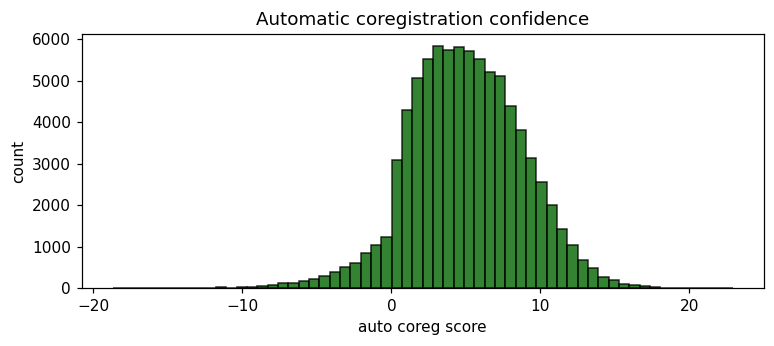

In [22]:
# Distribution of the auto 'score' (match confidence).
if 'score' in coreg_auto.columns:
    s = coreg_auto['score']
    print(f'auto coreg score: non-null {s.notna().sum()} / {len(s)}')
    print(s.describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(3))
    plt.figure(figsize=(8,3))
    plt.hist(s.dropna(), bins=60, color='darkgreen', edgecolor='black', alpha=0.8)
    plt.xlabel('auto coreg score'); plt.ylabel('count'); plt.title('Automatic coregistration confidence')
    plt.show()


In [23]:
# Does the manual table we already used agree with the auto table on (session, scan_idx, unit_id) for shared nuclei?
# Pick a sample of shared nuclei and compare their (session, scan_idx, unit_id) triples.
if {'target_id', 'session', 'scan_idx', 'unit_id'}.issubset(coreg_manual.columns) and \
   {'target_id', 'session', 'scan_idx', 'unit_id'}.issubset(coreg_auto.columns):

    shared = pd.merge(
        coreg_manual[['target_id', 'session', 'scan_idx', 'unit_id']].drop_duplicates(),
        coreg_auto[['target_id', 'session', 'scan_idx', 'unit_id', 'score']].drop_duplicates(),
        on='target_id', suffixes=('_manual', '_auto')
    )
    print('rows of shared target_ids (may be multiple scans per neuron):', len(shared))
    same_triple = (
        (shared['session_manual'] == shared['session_auto']) &
        (shared['scan_idx_manual'] == shared['scan_idx_auto']) &
        (shared['unit_id_manual']  == shared['unit_id_auto'])
    )
    print(f'triples identical manual ↔ auto: {same_triple.sum()} / {len(shared)}  ({100*same_triple.mean():.1f}%)')


rows of shared target_ids (may be multiple scans per neuron): 56190
triples identical manual ↔ auto: 16689 / 56190  (29.7%)


**Takeaway (Section 5):**

- Default (what Katia used in `exploration.ipynb`) is the manual table — highest trust, smaller population.
- Adding auto-coreg neurons would grow the training set but introduces label noise proportional to `1 - score`.
- Phase 8 (controls) will quantify the impact of swapping manual → auto on classifier accuracy. For the main pipeline we keep manual.


---

## 6. Population size under candidate filter combinations

This is the **decision table** for Phase 3. Each row is one candidate filter combination; columns are neuron counts per class/label of interest.


In [24]:
# Helper: consistent filter on units_best.
def pop(df, *, area=None, cell_type_notna=True, cc_min=None, matched=True,
        classification='excitatory_neuron', proofread=None):
    d = df.drop_duplicates('nucleus_id').copy()
    if classification:
        d = d[d['classification_system'] == classification]
    if matched and 'tuning_type' in d.columns:
        d = d[d['tuning_type'] == 'matched']
    if area is not None:
        if isinstance(area, str):
            d = d[d['brain_area'] == area]
        else:
            d = d[d['brain_area'].isin(area)]
    if cell_type_notna:
        d = d[d['cell_type'].notna()]
    if cc_min is not None and 'cc_abs' in d.columns:
        d = d[d['cc_abs'] >= cc_min]
    if proofread:
        d = fl.filter_neurons(d, proofread=proofread)
    return d


In [25]:
# Build the ub (units_best with layer attached) once, reuse across combos.
ub = units_best.copy()
layer_col = pd.Series(pd.NA, index=ub.index, dtype='object')
for L in ['L1', 'L2/3', 'L4', 'L5', 'L6']:
    sub = fl.filter_neurons(ub, layer=L)
    layer_col.loc[sub.index] = L
ub['layer'] = layer_col

combos = {
    'A — baseline (V1 exc, matched, labelled)':
        pop(ub, area='V1'),
    'B — A + cc_abs ≥ 0.2':
        pop(ub, area='V1', cc_min=0.2),
    'C — A + cc_abs ≥ 0.3':
        pop(ub, area='V1', cc_min=0.3),
    'D — A + proofread ax_clean':
        pop(ub, area='V1', proofread='ax_clean'),
    'E — multi-area V1/LM/AL/RL (exc, matched, labelled)':
        pop(ub, area=['V1', 'LM', 'AL', 'RL']),
}

rows = []
for name, d in combos.items():
    rows.append({
        'combo': name,
        'n_neurons': len(d),
        'n_L2/3': (d['layer'] == 'L2/3').sum(),
        'n_L4':   (d['layer'] == 'L4').sum(),
        'n_L5':   (d['layer'] == 'L5').sum(),
        'n_L6':   (d['layer'] == 'L6').sum(),
        'n_23P':  (d['cell_type'] == '23P').sum(),
        'n_4P':   (d['cell_type'] == '4P').sum(),
        'n_5P_IT':(d['cell_type'] == '5P-IT').sum(),
        'n_5P_ET':(d['cell_type'].isin(['5P-ET','5P-PT'])).sum(),
        'n_5P_NP':(d['cell_type'] == '5P-NP').sum(),
        'n_6P_IT':(d['cell_type'] == '6P-IT').sum(),
        'n_6P_CT':(d['cell_type'] == '6P-CT').sum(),
    })
decision = pd.DataFrame(rows).set_index('combo')
decision


,n_neurons,n_L2/3,n_L4,n_L5,n_L6,n_23P,n_4P,n_5P_IT,n_5P_ET,n_5P_NP,n_6P_IT,n_6P_CT
combo,,,,,,,,,,,,
"A — baseline (V1 exc, matched, labelled)",8910,4247,2670,1615,363,4213,2845,1169,320,26,216,121
B — A + cc_abs ≥ 0.2,8049,3757,2495,1520,264,3724,2657,1094,305,25,163,81
C — A + cc_abs ≥ 0.3,6738,3039,2156,1353,180,3009,2303,970,273,21,110,52
D — A + proofread ax_clean,728,246,309,121,51,243,334,76,24,2,29,20
"E — multi-area V1/LM/AL/RL (exc, matched, labelled)",12938,6060,4046,2325,485,6059,4143,1756,507,38,284,151


In [26]:
# Same table but percentages relative to baseline A, so we can see what each filter costs.
base = decision.loc['A — baseline (V1 exc, matched, labelled)']
pct = decision.div(base).mul(100).round(1)
pct


,n_neurons,n_L2/3,n_L4,n_L5,n_L6,n_23P,n_4P,n_5P_IT,n_5P_ET,n_5P_NP,n_6P_IT,n_6P_CT
combo,,,,,,,,,,,,
"A — baseline (V1 exc, matched, labelled)",100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
B — A + cc_abs ≥ 0.2,90.3,88.5,93.4,94.1,72.7,88.4,93.4,93.6,95.3,96.2,75.5,66.9
C — A + cc_abs ≥ 0.3,75.6,71.6,80.7,83.8,49.6,71.4,80.9,83.0,85.3,80.8,50.9,43.0
D — A + proofread ax_clean,8.2,5.8,11.6,7.5,14.0,5.8,11.7,6.5,7.5,7.7,13.4,16.5
"E — multi-area V1/LM/AL/RL (exc, matched, labelled)",145.2,142.7,151.5,144.0,133.6,143.8,145.6,150.2,158.4,146.2,131.5,124.8


**Reading the decision table:**

- Combo **A** is the starting point every other row modifies.
- Combo **B / C** show the population cost of a `cc_abs` quality filter — check especially the L5 and L6 columns, which are already small.
- Combo **D** shows how much the "proofread axon" filter costs; likely very aggressive.
- Combo **E** shows the population we would work with if we extend beyond V1.


---

## 7. Persist the candidate population & final takeaways


In [28]:
# Save the Combo A population so Phases 2–8 all reuse the same neurons.
# Phase 3 may tighten this further; this is the *candidate* population.
from pathlib import Path
out_dir = Path('data/derived'); out_dir.mkdir(parents=True, exist_ok=True)
candidate = combos['A — baseline (V1 exc, matched, labelled)']
candidate.to_parquet(out_dir / 'phase1_candidate_population.parquet')
print(f'saved {len(candidate)} rows to {out_dir/"phase1_candidate_population.parquet"}')


saved 8910 rows to data/derived/phase1_candidate_population.parquet


### Takeaways — Phase 1

1. **`functional_data='best_only'`** is the mode to use for the main units table (unique `nucleus_id`, single best scan per neuron, carries `cc_abs` and — verified above — `session/scan_idx/unit_id` too).
2. **`tuning_type == 'matched'`** is mandatory — non-matched neurons have no functional trace and cannot be used.
3. **Proofreading fields** are a label-quality lever, not a feature. The main pipeline does not filter on them; Phase 8 checks how much they cost/save.
4. **`cc_abs`** is a valid, label-independent quality filter. We will run Phase 6 on the full matched population, then test `cc_abs ≥ 0.2 / 0.3` in Phase 7.
5. **Manual coregistration** (`coregistration_manual_v4`) is our primary source. Automatic is kept as a Phase-8 robustness comparison.
6. The **candidate training population** saved for Phase 2+ is Combo A — matched V1 excitatory neurons with a non-null AIBS `cell_type`. Expected size: a few thousand neurons (exact number in the table above).
7. **V1 is the headline area**; multi-area (Combo E) is kept as a Phase 8 generalisation test.

### Open questions carried to Phase 3

- Do we keep `5P-NP` as its own class or merge it into a generic 5P bucket? Depends on final count in V1.
- Drop L1 (near-zero excitatory count) — essentially forced.
- 6P-IT vs 6P-CT split retained only if each has ≥ ~100 neurons with non-null label and cc_abs ≥ 0.2.
